#### IMPORTS

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from copy import copy
from env import env

from builders.classifiers.config import *
from builders.classifiers.wrapper import build_model

DEVICE = select_device(True)
DEFAULT = config(**env())[0]['model_conf']

Torch version: 2.3.0+rocm6.0
Using: AMD Radeon RX 6600
Torch version: 2.3.0+rocm6.0
Using: AMD Radeon RX 6600


/mnt/Source/kuznetsovmd/privacy-ontology/venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


#### CUDA

In [5]:
try:
    print(f'Using: {torch.cuda.get_device_name(DEVICE)}')
except ValueError:
    print(f'Using: CPU')

Using: AMD Radeon RX 6600


### NETWORK INSTANTIATION

In [6]:
m_defaults = copy(DEFAULT)
m_defaults['pretrained'] = True
m_defaults['version'] = 50
model = build_model(**m_defaults)

OK!


### PLOTS

[{'t_loss': 0.6461738260419775, 'v_loss': 0.9486248504521189, 't_accuracy': 0.7299133502598016, 'v_accuracy': 0.739501953125}, {'t_loss': 0.596908484089655, 'v_loss': 0.8918743063706854, 't_accuracy': 0.719984426665092, 'v_accuracy': 0.739501953125}, {'t_loss': 0.5620866233067683, 'v_loss': 0.6088820038154885, 't_accuracy': 0.8065059267241379, 'v_accuracy': 0.739501953125}, {'t_loss': 0.4768213108986902, 'v_loss': 0.588261428351997, 't_accuracy': 0.8213900862068966, 'v_accuracy': 0.73974609375}, {'t_loss': 0.4521681822894183, 'v_loss': 0.6193730499218639, 't_accuracy': 0.8254983836206896, 'v_accuracy': 0.74072265625}, {'t_loss': 0.44136410468387216, 'v_loss': 0.6242135135450959, 't_accuracy': 0.8302128232758621, 'v_accuracy': 0.74365234375}, {'t_loss': 0.4272745199057517, 'v_loss': 0.6074289922280316, 't_accuracy': 0.8356671808573453, 'v_accuracy': 0.748291015625}, {'t_loss': 0.40820536569506166, 'v_loss': 0.5997195213047486, 't_accuracy': 0.8450287110297591, 'v_accuracy': 0.7563476562

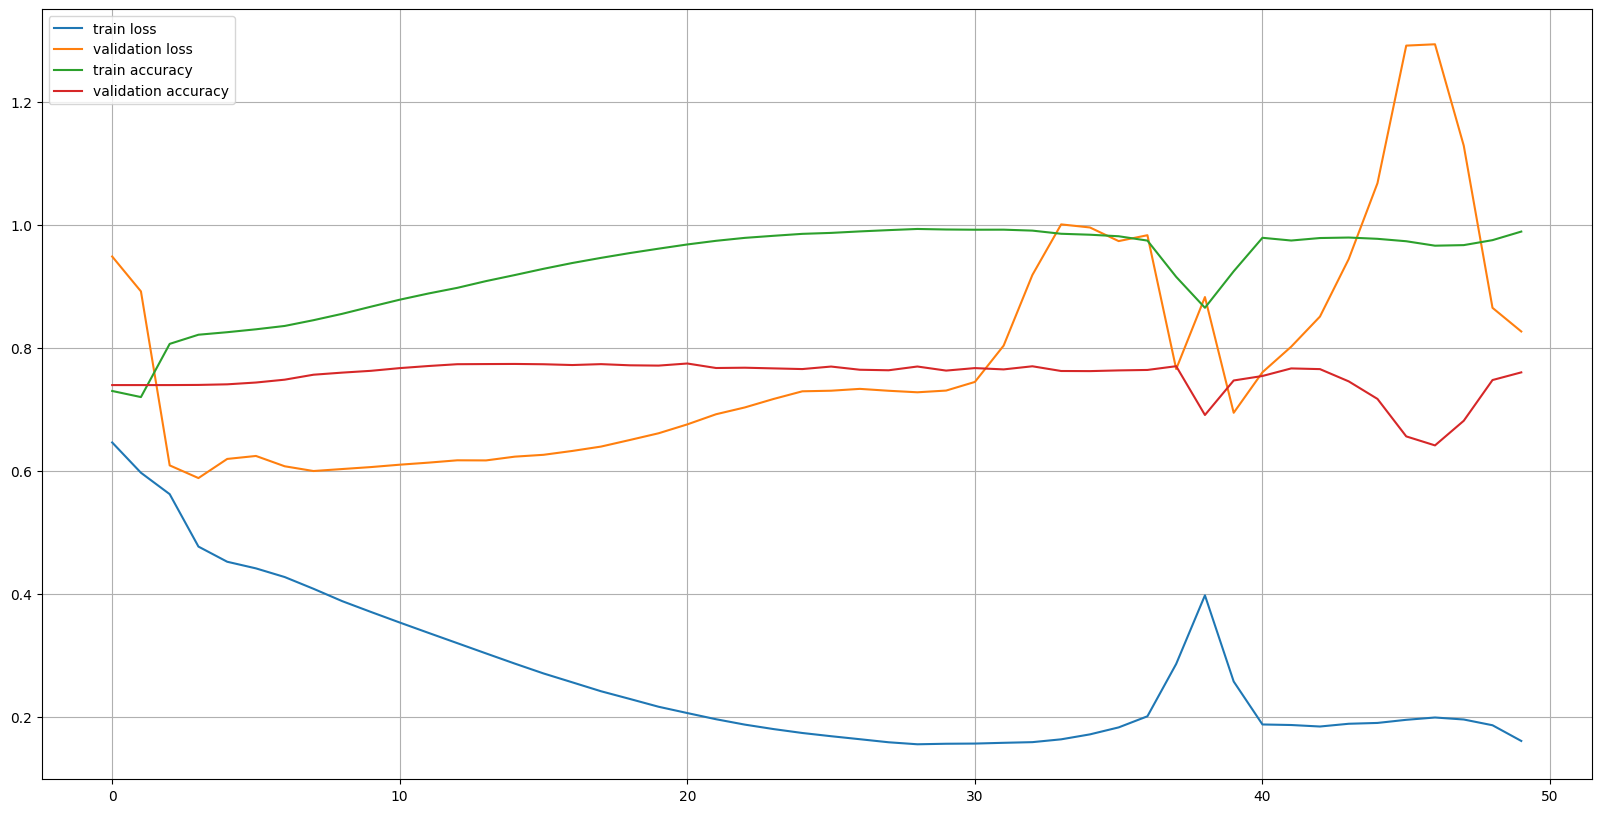

In [7]:
stats = model.stats_mem
print(model.stats_mem)
plt.figure(figsize=(20,10))
plt.grid()
plt.plot([s['t_loss'] for s in stats])
plt.plot([s['v_loss'] for s in stats])
plt.plot([s['t_accuracy'] for s in stats])
plt.plot([s['v_accuracy'] for s in stats])
plt.legend(['train loss', 'validation loss', 'train accuracy', 'validation accuracy'])
# plt.show()
plt.savefig('train.png')

print(f'TA={stats[-1]["t_accuracy"]}, VA={stats[-1]["v_accuracy"]}')

In [8]:
best = np.argmin([s['v_loss'] for s in stats])
print(f'best epoch: {best}, score: {stats[best]["t_accuracy"]}, score: {stats[best]["v_accuracy"]}')

best epoch: 3, score: 0.8213900862068966, score: 0.73974609375
